# Recovery consistency: same-conditioning agreement across campaigns, and the global structural landscape

Two questions:

**A. Cross-structure consistency.** `grind`, `ladder`, `promising`, `rfd_denovo30`, `rfd_maxcond` and
`rfd_recover` are six independently-launched campaigns that sometimes reuse the same named
conditioning (`mhc`, `tcr2`, `L1_nterm`...`L5_max`) or, in the case of `rfd_maxcond`'s `max` level and
`rfd_recover`'s ladder, the literal same 37/38-residue maximal hotspot set. If RFdiffusion's response to
a conditioning is deterministic-ish given the conditioning (not just noise), independently-launched
designs under the *same* hotspots should land in the *same* place. We check this from ground truth —
every design's sibling `.trb` records the exact `ppi.hotspot_res` actually used — not from filenames.

**B. The global landscape.** Pooling all ~650 locatable designs regardless of conditioning: even though
essentially none recover the native peptide exactly, is there a small number of frequently-revisited
structural basins (RFdiffusion has a few "default" folds it falls into), or is the space explored
genuinely diffuse (no structure in common across designs at all)? Answered with PCA + pairwise-RMSD
clustering on the frame-aligned peptide Cα traces (all already in one shared coordinate frame — the
groove frame from `score_denovo_designs._map_peptide` — so no additional superposition is needed).

In [1]:
import os, sys, pickle, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, "/home/ubuntu/if-mhc/py")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import score_denovo_designs as S
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
pd.set_option("display.width", 200)
ROOT = S.ROOT
OUT = f"{ROOT}/outputs/denovo_scores"
print("ready")

ready


## 1 · Build the master dataset

Every design across the six campaigns, frame-aligned peptide Cα (`pa`, shape (10,3)) plus, when a
sibling `.trb` exists, the *exact* `ppi.hotspot_res` set actually passed to RFdiffusion for that
specific design (ground truth — not inferred from the filename).

In [2]:
def load_trb_hotspots(pdb_path):
    trb = pdb_path[:-4] + ".trb"
    if not os.path.isfile(trb): return None, None
    try:
        d = pickle.load(open(trb, "rb"))
        cfg = d.get("config", {})
        hot = cfg.get("ppi", {}).get("hotspot_res")
        contig = cfg.get("contigmap", {}).get("contigs")
        return (frozenset(hot) if hot else frozenset()), (contig[0] if contig else None)
    except Exception:
        return None, None

DIRS = [f"{ROOT}/outputs/{x}/pdb" for x in ("grind", "ladder", "promising")] + \
       [f"{ROOT}/outputs/rfd_denovo30/pdb", f"{ROOT}/outputs/rfd_maxcond/pdb", f"{ROOT}/outputs/rfd_recover/pdb"]
files = S.gather(DIRS)
print(f"{len(files)} candidate PDBs across {len(DIRS)} campaign dirs")

rows, pas = [], []
for f in files:
    r = S._map_peptide(f)
    if r is None or r[0] is None: continue
    pa, tcr, plen = r
    meta = S.parse_meta(f)
    occ = S.occupancy(pa)
    toG = float(np.sqrt(((pa - S.GIG) ** 2).sum() / 10)); toD = float(np.sqrt(((pa - S.DRG) ** 2).sum() / 10))
    cog = toG if meta["pid"] == "6AM5" else toD; oth = toD if meta["pid"] == "6AM5" else toG
    hot, contig = load_trb_hotspots(f)
    rows.append(dict(**meta, file=f.replace(ROOT + "/", ""), tcr=tcr, to_cognate=cog, to_other=oth,
                     register=occ["register"], fpocket_pos=occ["fpocket_pos"], fpocket_dist=occ["fpocket_dist"],
                     threading=occ["threading"], n_hot=(len(hot) if hot is not None else None),
                     hotspots=(tuple(sorted(hot)) if hot else None), contig=contig))
    pas.append(pa)
M = pd.DataFrame(rows); PA = np.stack(pas)
M.drop(columns=["hotspots"]).to_csv(f"{OUT}/recovery_master.csv", index=False)
np.save(f"{OUT}/recovery_master_pa.npy", PA)
print(f"mapped {len(M)} designs; by source:")
print(M.groupby("source").size().to_string())
print(f"\nwrote {OUT}/recovery_master.csv + recovery_master_pa.npy")

1444 candidate PDBs across 6 campaign dirs


mapped 1358 designs; by source:
source
denovo30       214
grind           20
ladder          30
maxcond        291
promising      733
rfd_recover     70

wrote /home/ubuntu/if-mhc/outputs/denovo_scores/recovery_master.csv + recovery_master_pa.npy


## 2A · Exact-hotspot-set groups spanning ≥2 campaigns (ground truth)

Group by `(pid, hotspot-set)`. Only keep groups whose designs come from **more than one** campaign —
those are cases where two independently-launched runs were handed the literal same conditioning.

In [3]:
has_hot = M[M.hotspots.notna()].copy()
grp_key = list(zip(has_hot.pid, has_hot.hotspots))
has_hot["hgroup"] = grp_key
gsizes = has_hot.groupby("hgroup")["source"].nunique()
shared_keys = gsizes[gsizes >= 2].index
print(f"{len(shared_keys)} exact hotspot-set(s) reused verbatim across >=2 campaigns")

exact_rows = []
for pid, hot in shared_keys:
    sub = has_hot[(has_hot.pid == pid) & (has_hot.hotspots == hot)]
    pas_sub = PA[sub.index.values]
    for src in sub.source.unique():
        s = sub[sub.source == src]
        p = PA[s.index.values]
        if len(p) >= 2:
            d = p[:, None] - p[None, :]; rm = np.sqrt((d ** 2).sum(-1).mean(-1))
            iu = np.triu_indices(len(p), k=1); self_rmsd = float(rm[iu].mean())
        else:
            self_rmsd = np.nan
        exact_rows.append(dict(pid=pid, n_hot=len(hot), source=src, n=len(s),
                               to_cog_med=round(float(s.to_cognate.median()), 2),
                               self_rmsd=round(self_rmsd, 2) if self_rmsd == self_rmsd else None,
                               register_mode=s.register.mode().iat[0]))
    d = pas_sub[:, None] - pas_sub[None, :]; rm = np.sqrt((d ** 2).sum(-1).mean(-1))
    iu = np.triu_indices(len(pas_sub), k=1)
    exact_rows.append(dict(pid=pid, n_hot=len(hot), source="__POOLED_ACROSS_SOURCES__", n=len(sub),
                           to_cog_med=round(float(sub.to_cognate.median()), 2),
                           self_rmsd=round(float(rm[iu].mean()), 2), register_mode=sub.register.mode().iat[0]))
EXACT = pd.DataFrame(exact_rows).sort_values(["pid", "n_hot", "source"])
EXACT

18 exact hotspot-set(s) reused verbatim across >=2 campaigns


,pid,n_hot,source,n,to_cog_med,self_rmsd,register_mode
29,6AM5,2,__POOLED_ACROSS_SOURCES__,10,9.59,11.28,off
28,6AM5,2,denovo30,6,8.56,11.45,off
27,6AM5,2,grind,4,9.89,12.83,off
15,6AM5,3,__POOLED_ACROSS_SOURCES__,87,12.58,10.81,off
14,6AM5,3,denovo30,24,12.84,10.03,off
12,6AM5,3,ladder,3,3.33,11.35,off
13,6AM5,3,promising,60,8.21,10.80,off
26,6AM5,4,__POOLED_ACROSS_SOURCES__,69,12.97,10.72,off
25,6AM5,4,denovo30,6,11.45,12.89,off
23,6AM5,4,ladder,3,3.73,12.58,off


If cross-campaign designs under the *same* hotspots land in the same place, the pooled
(`__POOLED_ACROSS_SOURCES__`) self-RMSD should be close to the per-source self-RMSD values above it —
not dramatically larger. A pooled value much bigger than every individual source's own self-RMSD means
the campaigns landed in *different* basins despite identical conditioning.

## 2B · 3D overlay of the largest exact-match group, colored by campaign

Visual check for the biggest shared-hotspot group: do the campaigns' traces sit on top of each other?

largest exact-match group: pid=6AM5, n_hot=9, sources=['ladder', 'promising'], n=136


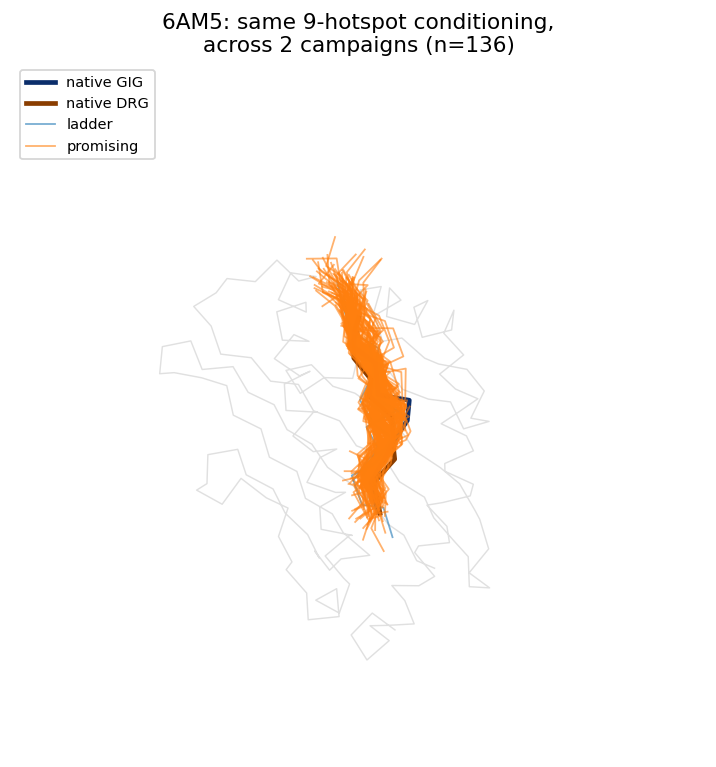

In [4]:
biggest = has_hot[has_hot.hgroup.isin(shared_keys)].groupby("hgroup").size().idxmax()
pid0, hot0 = biggest
sub = has_hot[(has_hot.pid == pid0) & (has_hot.hotspots == hot0)]
print(f"largest exact-match group: pid={pid0}, n_hot={len(hot0)}, sources={sorted(sub.source.unique())}, n={len(sub)}")

fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection="3d")
allpts = np.vstack([S.REF_CA, PA[sub.index.values].reshape(-1, 3), S.GIG, S.DRG]); ctr = allpts.mean(0)
rad = np.percentile(np.linalg.norm(allpts - ctr, axis=1), 98) * 1.05
ax.set_xlim(ctr[0]-rad, ctr[0]+rad); ax.set_ylim(ctr[1]-rad, ctr[1]+rad); ax.set_zlim(ctr[2]-rad, ctr[2]+rad)
ax.view_init(elev=18, azim=-60); ax.set_box_aspect((1, 1, 1)); ax.set_axis_off()
ax.plot(*S.REF_CA.T, color="0.8", lw=0.8, alpha=0.6)
ax.plot(*S.GIG.T, color="#0b2e6b", lw=2.6, label="native GIG")
ax.plot(*S.DRG.T, color="#8a3d00", lw=2.6, label="native DRG")
cmap = plt.get_cmap("tab10")
for i, src in enumerate(sorted(sub.source.unique())):
    idx = sub[sub.source == src].index.values
    for j, k in enumerate(idx):
        ax.plot(*PA[k].T, color=cmap(i), lw=1.0, alpha=0.6, label=(src if j == 0 else None))
ax.legend(fontsize=8, loc="upper left"); ax.set_title(f"{pid0}: same {len(hot0)}-hotspot conditioning,\nacross {sub.source.nunique()} campaigns (n={len(sub)})")
plt.tight_layout(); plt.savefig(f"{OUT}/recovery_exact_overlay.png", dpi=150); plt.show()

## 2C · Near-duplicate ladder rungs — same *name*, slightly evolved hotspot set

`L1_nterm`...`L5_max`, `mhc`, `tcr1`, `tcr2` recur by NAME across campaigns, but the exact hotspot list
was refined between launches (e.g. `ladder`'s `L4_expanded` adds `E96` that `rfd_denovo30`'s doesn't).
Quantify the overlap with Jaccard similarity, then compare accuracy/consistency per source anyway.

In [5]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / max(1, len(a | b))

near_rows = []
for (pid, cond), g in has_hot.groupby(["pid", "cond"]):
    srcs = sorted(g.source.unique())
    if len(srcs) < 2: continue
    for i in range(len(srcs)):
        for j in range(i + 1, len(srcs)):
            hi = g[g.source == srcs[i]].hotspots.iloc[0]; hj = g[g.source == srcs[j]].hotspots.iloc[0]
            near_rows.append(dict(pid=pid, cond=cond, src_i=srcs[i], src_j=srcs[j], jaccard=round(jaccard(hi, hj), 2),
                                  n_i=len(hi), n_j=len(hj)))
NEAR = pd.DataFrame(near_rows).sort_values("jaccard", ascending=False)
NEAR

,pid,cond,src_i,src_j,jaccard,n_i,n_j
0,6AM5,L1_nterm,denovo30,ladder,1.00,3,3
1,6AM5,L1_nterm,denovo30,promising,1.00,3,3
2,6AM5,L1_nterm,ladder,promising,1.00,3,3
5,6AM5,L2_nterm_t1,ladder,promising,1.00,4,4
29,6AMU,L4_expanded,ladder,promising,1.00,9,9
8,6AM5,L3_nterm_t2,ladder,promising,1.00,5,5
11,6AM5,L4_expanded,ladder,promising,1.00,9,9
19,6AMU,L1_nterm,denovo30,promising,1.00,3,3
17,6AM5,tcr2,denovo30,grind,1.00,2,2
18,6AMU,L1_nterm,denovo30,ladder,1.00,3,3


In [6]:
summ_rows = []
for (pid, cond), g in has_hot.groupby(["pid", "cond"]):
    if g.source.nunique() < 2: continue
    for src in sorted(g.source.unique()):
        s = g[g.source == src]; p = PA[s.index.values]
        if len(p) >= 2:
            d = p[:, None] - p[None, :]; rm = np.sqrt((d ** 2).sum(-1).mean(-1)); iu = np.triu_indices(len(p), k=1)
            self_rmsd = float(rm[iu].mean())
        else:
            self_rmsd = np.nan
        summ_rows.append(dict(pid=pid, cond=cond, source=src, n=len(s),
                              to_cog_med=round(float(s.to_cognate.median()), 2),
                              self_rmsd=round(self_rmsd, 2) if self_rmsd == self_rmsd else None,
                              register_mode=s.register.mode().iat[0]))
NEARSUM = pd.DataFrame(summ_rows).sort_values(["pid", "cond", "source"])
NEARSUM

,pid,cond,source,n,to_cog_med,self_rmsd,register_mode
0,6AM5,L1_nterm,denovo30,12,12.84,10.07,off
1,6AM5,L1_nterm,ladder,3,3.33,11.35,off
2,6AM5,L1_nterm,promising,60,8.21,10.80,off
3,6AM5,L2_nterm_t1,denovo30,12,12.75,11.71,off
4,6AM5,L2_nterm_t1,ladder,3,3.73,12.58,off
5,6AM5,L2_nterm_t1,promising,60,13.27,10.68,off
6,6AM5,L3_nterm_t2,denovo30,12,13.17,10.91,off
7,6AM5,L3_nterm_t2,ladder,3,14.52,3.85,off
8,6AM5,L3_nterm_t2,promising,86,13.82,10.30,off
9,6AM5,L4_expanded,denovo30,12,10.52,10.05,off


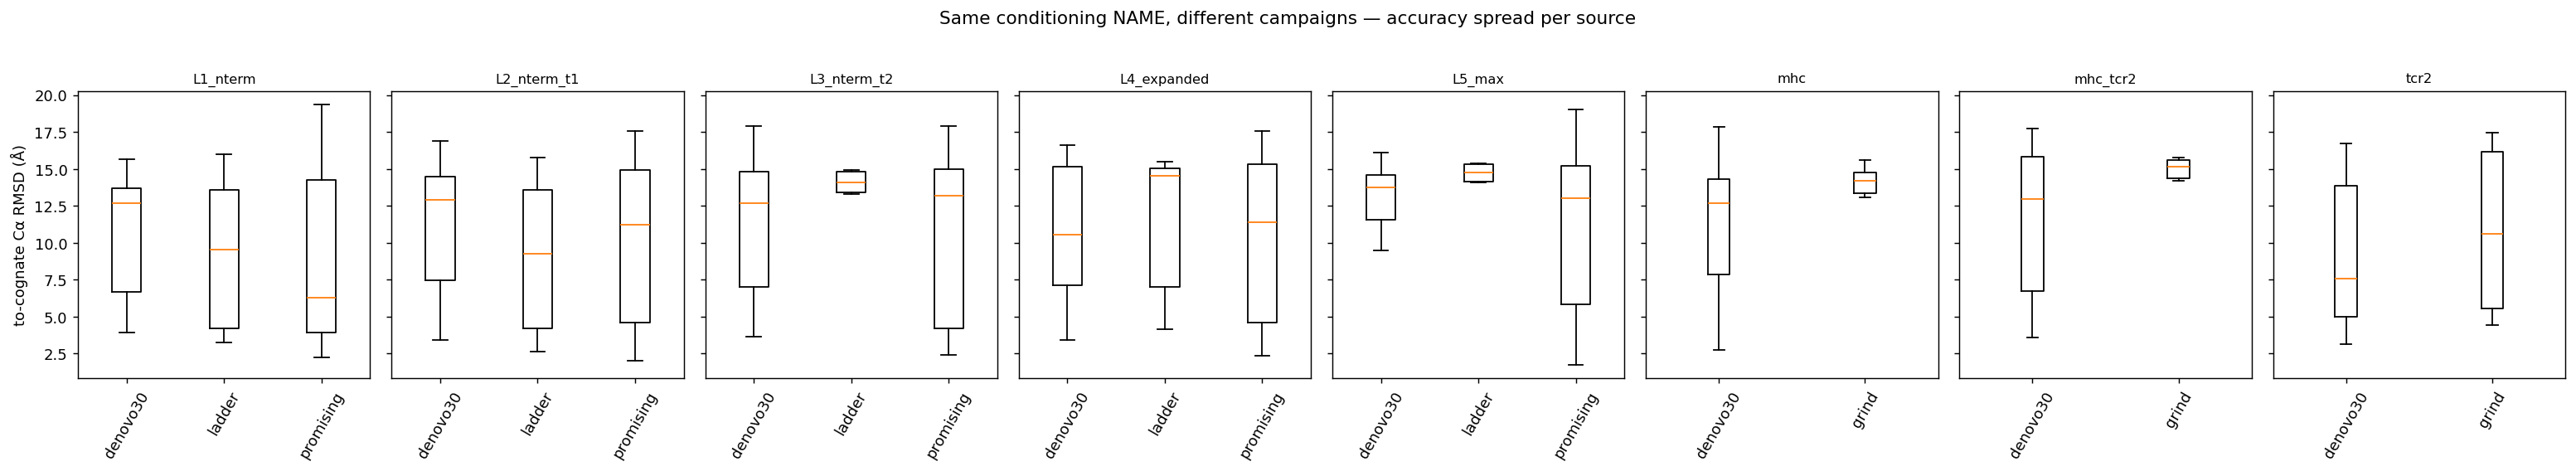

In [7]:
conds = NEARSUM.cond.unique()
fig, axes = plt.subplots(1, len(conds), figsize=(3.0 * len(conds), 4.2), sharey=True)
if len(conds) == 1: axes = [axes]
for ax, cond in zip(axes, conds):
    sub = has_hot[has_hot.cond == cond]
    srcs = sorted(sub.source.unique())
    data = [sub[sub.source == s].to_cognate.values for s in srcs]
    ax.boxplot(data, labels=srcs, showfliers=False)
    ax.set_title(cond, fontsize=9); ax.tick_params(axis="x", rotation=60)
axes[0].set_ylabel("to-cognate Cα RMSD (Å)")
fig.suptitle("Same conditioning NAME, different campaigns — accuracy spread per source", y=1.03)
plt.tight_layout(); plt.savefig(f"{OUT}/recovery_near_boxplots.png", dpi=150); plt.show()

## 3 · The global landscape — is there a frequent space, pooling ALL designs?

Every locatable design, regardless of conditioning or campaign, projected and clustered in the shared
groove frame.

explained variance: [0.719 0.161]


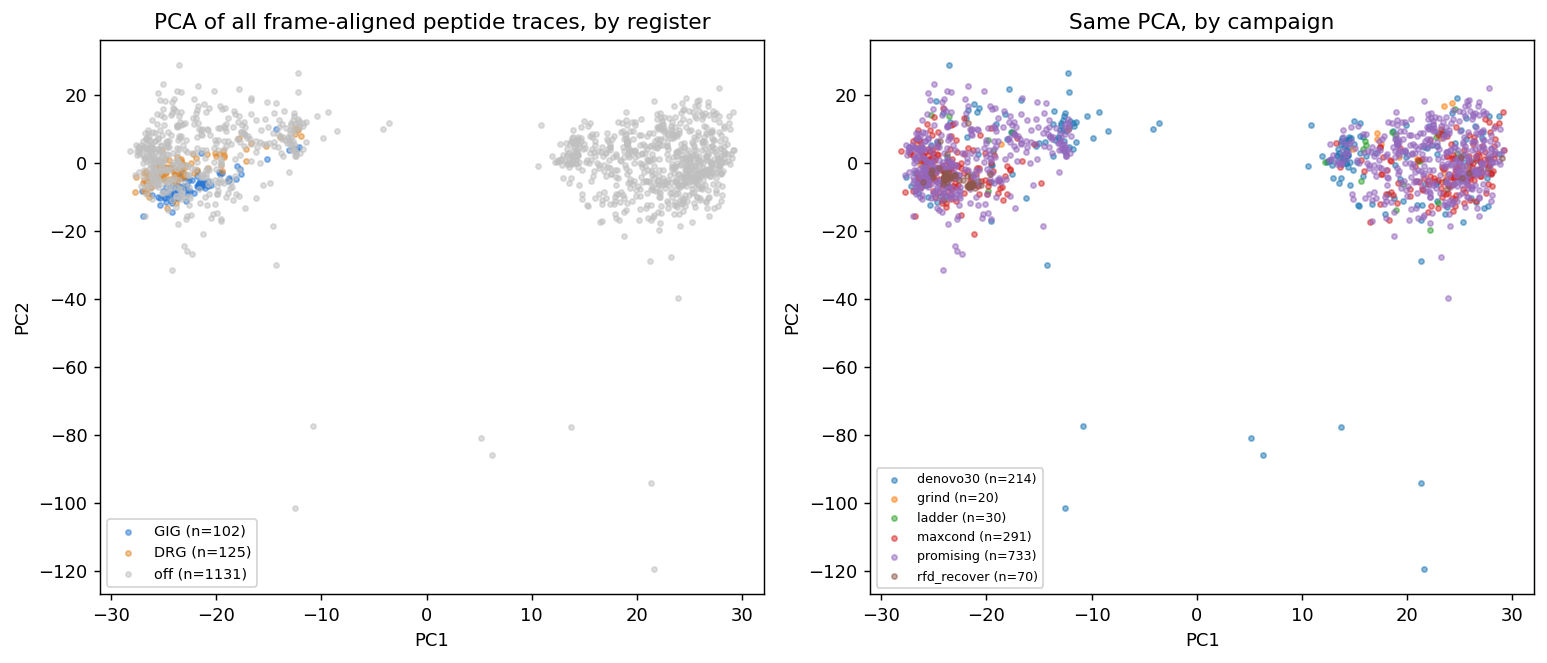

In [8]:
flat = PA.reshape(len(PA), -1)
pca = PCA(n_components=2).fit(flat)
xy = pca.transform(flat)
print(f"explained variance: {pca.explained_variance_ratio_[:2].round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
regcolor = {"GIG": "#2a78d6", "DRG": "#e08a2e", "off": "0.75"}
for reg, c in regcolor.items():
    m = M.register == reg
    axes[0].scatter(xy[m.values, 0], xy[m.values, 1], s=8, alpha=.5, color=c, label=f"{reg} (n={m.sum()})")
axes[0].legend(fontsize=8); axes[0].set_title("PCA of all frame-aligned peptide traces, by register")
srcs = sorted(M.source.unique()); cmap = plt.get_cmap("tab10")
for i, src in enumerate(srcs):
    m = (M.source == src).values
    axes[1].scatter(xy[m, 0], xy[m, 1], s=8, alpha=.5, color=cmap(i), label=f"{src} (n={m.sum()})")
axes[1].legend(fontsize=7); axes[1].set_title("Same PCA, by campaign")
for ax in axes: ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.savefig(f"{OUT}/recovery_pca.png", dpi=150); plt.show()

### Pairwise-RMSD distance matrix — where's the natural cluster-merge scale?

Histogram of every pairwise Cα-RMSD across the whole pool. A bimodal shape (a within-basin mode, a gap,
a between-basin mode) gives a principled distance threshold for clustering — no need to guess one.

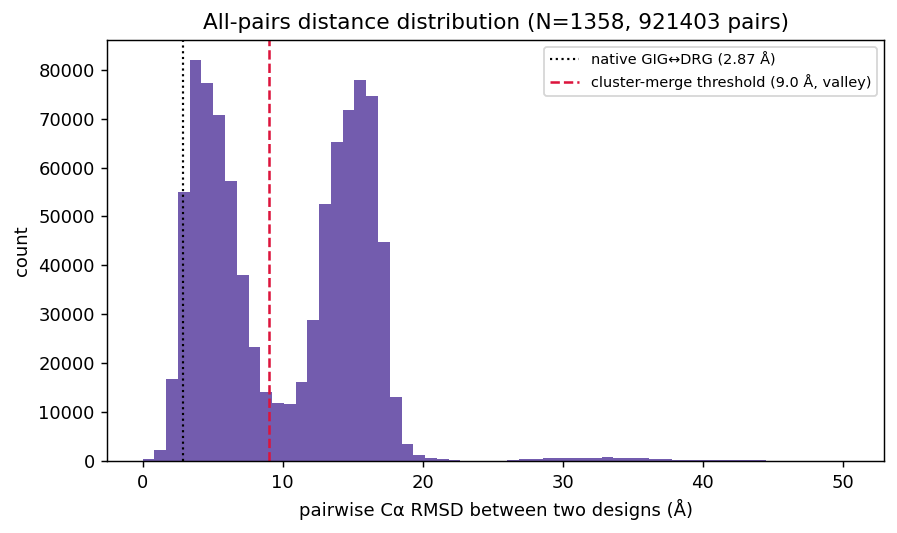

In [9]:
N = len(PA)
d = PA[:, None] - PA[None, :]
RM = np.sqrt((d ** 2).sum(-1).mean(-1))
iu = np.triu_indices(N, k=1); vals = RM[iu]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(vals, bins=60, color="#5b3fa0", alpha=.85)
ax.axvline(2.87, color="k", ls=":", lw=1.2, label="native GIG↔DRG (2.87 Å)")
THRESH = 9.0
ax.axvline(THRESH, color="crimson", ls="--", lw=1.4, label=f"cluster-merge threshold ({THRESH} Å, valley)")
ax.set_xlabel("pairwise Cα RMSD between two designs (Å)"); ax.set_ylabel("count")
ax.set_title(f"All-pairs distance distribution (N={N}, {len(vals)} pairs)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/recovery_pairwise_hist.png", dpi=150); plt.show()

### Cluster with the empirical threshold — how many recurring basins, how big?

Average-linkage agglomerative clustering directly on the precomputed RMSD matrix, merged at the
histogram's valley. Reports whether a handful of basins absorb most designs (a frequent, reused space)
or whether cluster sizes are flat (genuinely diffuse, no shared structure).

In [10]:
clu = AgglomerativeClustering(n_clusters=None, distance_threshold=THRESH, metric="precomputed", linkage="average")
labels = clu.fit_predict(RM)
M2 = M.copy(); M2["cluster"] = labels
sizes = M2.cluster.value_counts()
print(f"{len(sizes)} clusters at {THRESH} Å merge distance; top 10 by size:")
top10 = sizes.head(10)
print(top10.to_string())
print(f"\ntop-5 clusters hold {100*sizes.head(5).sum()/len(M2):.0f}% of all {len(M2)} designs")
print(f"largest single cluster: {sizes.iloc[0]} designs ({100*sizes.iloc[0]/len(M2):.0f}%)")

comp_rows = []
for cl in top10.index:
    s = M2[M2.cluster == cl]
    comp_rows.append(dict(cluster=cl, n=len(s), register_mode=s.register.mode().iat[0],
                          register_purity=round((s.register == s.register.mode().iat[0]).mean(), 2),
                          n_sources=s.source.nunique(), sources=",".join(sorted(s.source.unique())),
                          n_conds=s.cond.nunique(), to_cog_med=round(s.to_cognate.median(), 2)))
pd.DataFrame(comp_rows)

12 clusters at 9.0 Å merge distance; top 10 by size:
cluster
2     673
1     665
0       6
3       5
7       2
11      1
5       1
9       1
10      1
4       1

top-5 clusters hold 99% of all 1358 designs
largest single cluster: 673 designs (50%)


,cluster,n,register_mode,register_purity,n_sources,sources,n_conds,to_cog_med
0,2,673,off,0.66,6,"denovo30,grind,ladder,maxcond,promising,rfd_re...",19,4.07
1,1,665,off,1.00,6,"denovo30,grind,ladder,maxcond,promising,rfd_re...",15,15.02
2,0,6,off,1.00,2,"denovo30,promising",3,15.70
3,3,5,off,1.00,2,"denovo30,promising",3,7.87
4,7,2,off,1.00,1,denovo30,2,29.20
5,11,1,off,1.00,1,denovo30,1,13.90
6,5,1,off,1.00,1,denovo30,1,32.90
7,9,1,off,1.00,1,denovo30,1,27.75
8,10,1,off,1.00,1,denovo30,1,34.51
9,4,1,off,1.00,1,denovo30,1,12.58


If a top cluster's `sources` column lists several different campaigns AND `n_conds` is large, that
cluster is a **generic attractor** — RFdiffusion falls into it regardless of what it was told to do,
which is a much stronger and more useful claim than saying "these designs happen to be similar".

In [11]:
comp_rows2 = []
for cl in top10.index:
    s = M2[M2.cluster == cl]
    vc = s.threading.value_counts(normalize=True)
    comp_rows2.append(dict(cluster=cl, n=len(s),
                           frac_forward=round(vc.get("forward", 0.0), 2),
                           frac_reverse=round(vc.get("reverse", 0.0), 2),
                           frac_ambiguous=round(vc.get("ambiguous", 0.0), 2),
                           to_cog_med=round(s.to_cognate.median(), 2)))
pd.DataFrame(comp_rows2)

,cluster,n,frac_forward,frac_reverse,frac_ambiguous,to_cog_med
0,2,673,0.96,0.01,0.03,4.07
1,1,665,0.00,0.95,0.05,15.02
2,0,6,0.00,1.00,0.00,15.70
3,3,5,1.00,0.00,0.00,7.87
4,7,2,0.00,1.00,0.00,29.20
5,11,1,1.00,0.00,0.00,13.90
6,5,1,0.00,1.00,0.00,32.90
7,9,1,1.00,0.00,0.00,27.75
8,10,1,0.00,1.00,0.00,34.51
9,4,1,0.00,0.00,1.00,12.58


### Are the "generic attractor" clusters just the forward/reverse-threading split?

A structurally distinct population was found late in this project: with nothing constraining peptide
N->C direction, unconditioned RFdiffusion buries either its C-terminal anchor (**forward** — like both
native registers) or its N-terminal anchor (**reverse** — a mirror-image threading) at roughly 50/50
odds, regardless of conditioning (`threading` field in `score_denovo_designs.py`). If the two dominant
"generic attractor" clusters above are near-pure forward/reverse (not a mix), the frequent-space finding
in this section is **that artifact**, not a separate discovery about RFdiffusion's fold preferences.

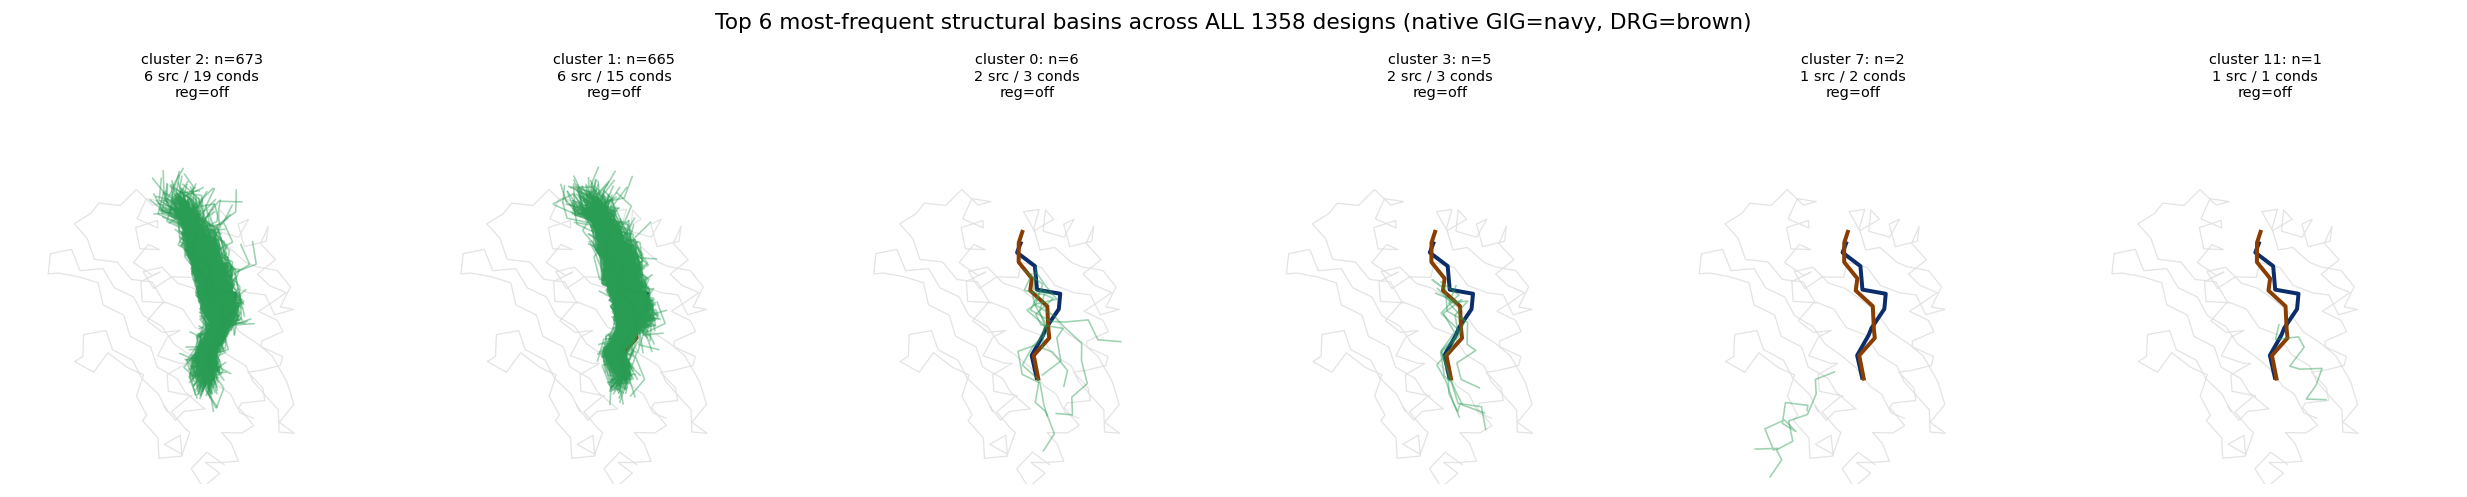

In [12]:
K = min(6, len(top10))
fig = plt.figure(figsize=(3.2 * K, 3.6))
allpts = np.vstack([S.REF_CA, PA.reshape(-1, 3), S.GIG, S.DRG]); ctr = allpts.mean(0)
rad = np.percentile(np.linalg.norm(allpts - ctr, axis=1), 98) * 1.05
for i, cl in enumerate(top10.index[:K]):
    ax = fig.add_subplot(1, K, i + 1, projection="3d")
    ax.set_xlim(ctr[0]-rad, ctr[0]+rad); ax.set_ylim(ctr[1]-rad, ctr[1]+rad); ax.set_zlim(ctr[2]-rad, ctr[2]+rad)
    ax.view_init(elev=18, azim=-60); ax.set_box_aspect((1, 1, 1)); ax.set_axis_off()
    ax.plot(*S.REF_CA.T, color="0.82", lw=0.7, alpha=0.6)
    ax.plot(*S.GIG.T, color="#0b2e6b", lw=2.2); ax.plot(*S.DRG.T, color="#8a3d00", lw=2.2)
    idx = M2[M2.cluster == cl].index.values
    for k in idx:
        ax.plot(*PA[k].T, color="#2a9d55", lw=0.9, alpha=.45)
    s = M2.loc[idx]
    ax.set_title(f"cluster {cl}: n={len(idx)}\n{s.source.nunique()} src / {s.cond.nunique()} conds\nreg={s.register.mode().iat[0]}", fontsize=8)
fig.suptitle(f"Top {K} most-frequent structural basins across ALL {len(M2)} designs (native GIG=navy, DRG=brown)", y=1.05)
plt.tight_layout(); plt.savefig(f"{OUT}/recovery_top_clusters_3d.png", dpi=150); plt.show()

## Readout

- **Section 2A/2B** answer whether identical conditioning reproduces the same structure across
  independently-launched campaigns — the pooled-vs-per-source self-RMSD comparison is the direct test.
- **Section 2C** shows how much the ladder's named rungs actually drifted between campaign refinements
  (Jaccard), and whether that drift changed the outcome.
- **Section 3** is the frequent-space question: the cluster-size table and the top-cluster composition
  say whether RFdiffusion, when it doesn't recover the native peptide, still falls into a **small,
  reused set of default folds** (few big clusters, multi-campaign/multi-conditioning composition) or
  is genuinely unstructured noise (flat cluster-size distribution, most clusters singletons).